# Topic 2: Predictive Modeling
In this notebook, Topic 2 is executed, in particular, option 3: Mode choice prediction is performed.

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, cross_validate, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score, PrecisionRecallDisplay
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap
from scipy.stats import randint, uniform


# Data inspection

In [9]:
df_odin = pl.read_excel('data/ODiN2024 Updated with Header/ODiN2024_DANS_Databestand_ Updated.xlsx').to_pandas()
df_odin.head()

,OP,OPID,Mode,HHPers_DANS24,HHSam_DANS24,HHLft1_DANS24,HHLft2_DANS24,HHLft3_DANS24,HHLft4_DANS24,Wogem_DANS24,...,RAankUur,RAankMin,RReisduur,RReisduurBL,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1,350000661958,1,2,2,0,0,0,2,995,...,15.0,0.0,120.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
1,0,350000661958,1,2,2,0,0,0,2,995,...,17.0,0.0,60.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
2,0,350000661958,1,2,2,0,0,0,2,995,...,22.0,0.0,105.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
3,1,350000773958,1,2,2,0,0,0,2,1740,...,8.0,55.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908
4,0,350000773958,1,2,2,0,0,0,2,1740,...,18.0,50.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908


In [10]:
missing = df_odin.isnull().sum()
missing_pct = (missing / len(df_odin) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing count": missing,
    "Missing %": missing_pct,
    "Non-missing": df_odin.notnull().sum(),
    "Dtype": df_odin.dtypes
}).sort_values("Missing %", ascending=False)

print(missing_summary.to_string())

                     Missing count  Missing %  Non-missing    Dtype
AfstS                       212514      99.57          909  float64
SDezPlts                    212514      99.57          909  float64
SAantAdr                    212514      99.57          909  float64
SEindMin                    212514      99.57          909  float64
SEindUur                    212514      99.57          909  float64
SBegMin                     212514      99.57          909  float64
SBegUur                     212514      99.57          909  float64
SVvm4                       212514      99.57          909  float64
SVvm3                       212514      99.57          909  float64
SVvm2                       212514      99.57          909  float64
SVvm1                       212514      99.57          909  float64
AfstSBL                     212514      99.57          909  float64
ActDuur                      78536      36.80       134887  float64
AfstR                        14815       6.94   

# Data preprocessing

In [ ]:
# Target is KHvm, so we dont select columns that could leak data

df = df_odin[[
    'KHvm', 'OPID',
    'AfstV', 'KVertTijd', 'Weekdag', 'Maand', 'VertLoc', 'Doel',
    'KLeeft', 'Geslacht', 'Opleiding_DANS24', 'BetWerk', 'OPRijbewijsAu',
    'HHGestInkG', 'HHPers_DANS24', 'HHSam_DANS24',
    'HHAuto_DANS24', 'HHRijbewijsAu', 'OPAuto_DANS24',
    'HHBrSn_DANS24', 'HHEFiets_DANS24', 'OVStKaart',
    'Sted', 'Prov', 'VertGem_DANS24', 'GemGr', 'Corop',
    'FqLopen', 'FqNEFiets', 'FqEFiets', 'FqBTM', 'FqTrein',
    'FqAutoB', 'FqAutoP', 'FqBrSnor',
    'WrkVervw', 'WrkVerg', 'VergOV',
    'BrbWrk', 'BrbOnd', 'BrbSport',
]].copy().dropna()

## RF based feature selection

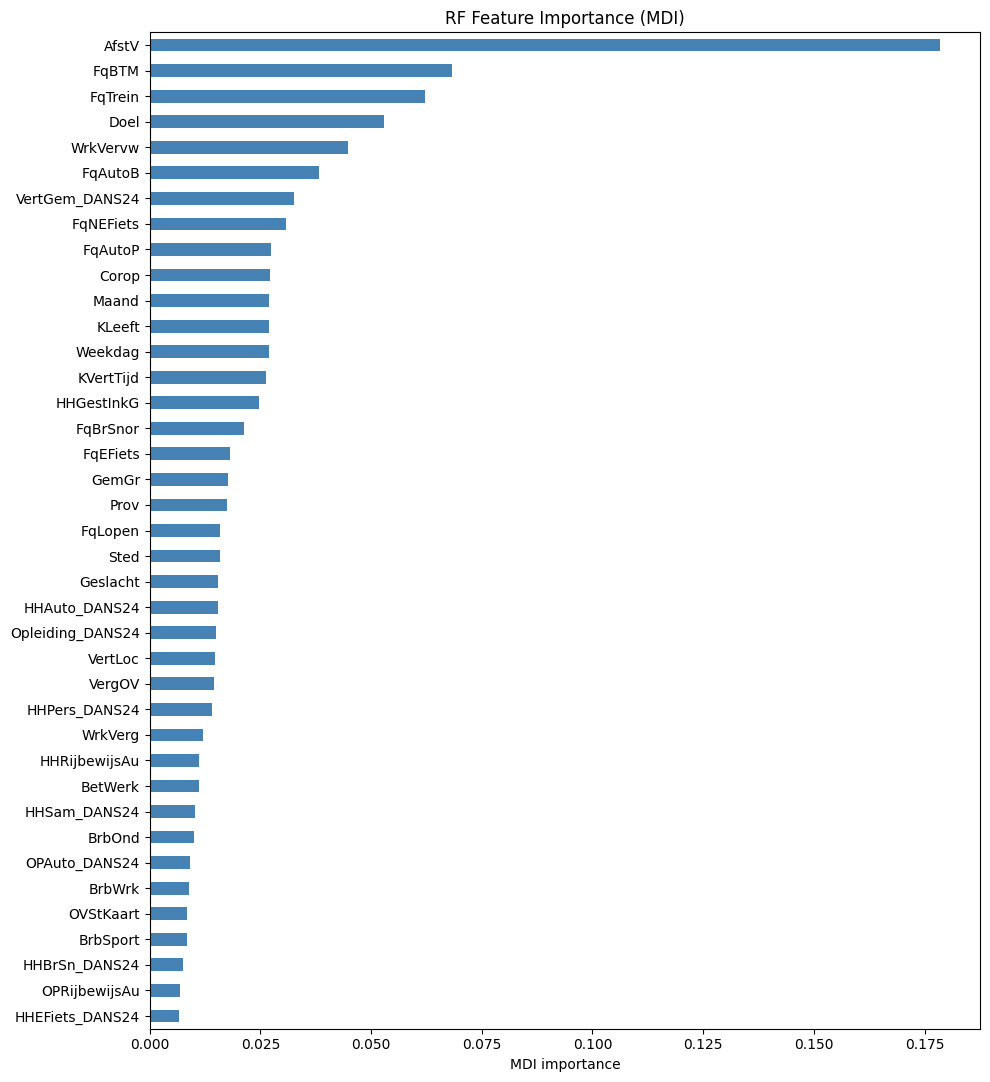

In [ ]:
X_full = df.drop(columns=['KHvm','OPID']).copy()
# KHVm is 1-7, we want 0-6 for Models
y = df['KHvm'].astype(int)-1
# Grouping based on OPID to keep avoid data leakage
groups = df['OPID']

# Class labels from codebook
class_labels = {
    0: "Car-driver",
    1: "Car-passenger",
    2: "Train",
    3: "BTM",
    4: "Bike",
    5: "Walking",
    6: "Other"
}

# For use in classification_report and confusion matrix
label_names = [class_labels[i] for i in sorted(class_labels.keys())]

# Converting all columns to numeric
for col in X_full.columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce')
X_full = X_full.fillna(X_full.median(numeric_only=True))


# Creating train and test splits
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

train_idx, test_idx = next(gss.split(X_full, y, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# We use tree based models, so we only scale the numeric scale AfstV (distance)
# Other columns we can keep as is, as this would require a lot more data preprocessing
preprocessor = ColumnTransformer(
    [("num", StandardScaler(), ["AfstV"])],
    remainder="passthrough"
)
# Using RF feature importance with a basic RF classifier
rf_sel = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

sel_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_sel)
])

sel_pipe.fit(X_train, y_train)

# Cleaning feature names for plot
feature_names_clean = [
    f.replace("remainder__", "").replace("num__", "")
    for f in sel_pipe.named_steps["preprocessor"].get_feature_names_out()
]
# Mean Ddecrease in Impurity (MDI) is used to rank features
mdi = pd.Series(
    sel_pipe.named_steps["classifier"].feature_importances_,
    index=feature_names_clean
).sort_values(ascending=False)

# Plot MDI
mdi.sort_values().plot(kind="barh", figsize=(10, max(6, len(mdi) * 0.28)), color="steelblue")
plt.xlabel("MDI importance")
plt.title("RF Feature Importance (MDI)")
plt.tight_layout()
plt.savefig("feature_importance_mdi.png", dpi=150)
plt.show()


### 

In [ ]:
# Many features are not important, so we select top k features, this code cell investigates how many top k features to keep.
gkf5 = StratifiedGroupKFold(n_splits=5)

for top_n in [15, 20, 25, 30, 40]:
    selected = mdi.head(top_n).index.tolist()
    X_sel = X_train[selected]


    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced_subsample",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv = cross_validate(pipe, X_sel, y_train, cv=gkf5, groups=groups_train,
                        scoring=["accuracy", "f1_macro"], n_jobs=-1)

    print(f"Top {top_n}: accuracy={cv['test_accuracy'].mean():.4f}, "
          f"f1_macro={cv['test_f1_macro'].mean():.4f}")

Top 15: accuracy=0.7017, f1_macro=0.6479
Top 20: accuracy=0.7164, f1_macro=0.6673
Top 25: accuracy=0.7214, f1_macro=0.6744
Top 30: accuracy=0.7194, f1_macro=0.6728
Top 35: accuracy=0.7177, f1_macro=0.6699
Top 40: accuracy=0.7179, f1_macro=0.6695
Top 50: accuracy=0.7179, f1_macro=0.6695


Selecting top 25 features for the model.

# Modeling

## Baseline Models

In [ ]:
# Selecting Top 25 features
top_25 = mdi.head(25).index.tolist()
X = X_train[top_25].copy()
X_test = X_test[top_25].copy()

# Baseline models
gkf5 = StratifiedGroupKFold(n_splits=5)


baseline_models = {
    "RF baseline": RandomForestClassifier(
        n_estimators=500, class_weight="balanced_subsample",
        min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    "XGBoost baseline": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss", random_state=42, n_jobs=-1
    )
}

print("Baseline Models")
for name, model in baseline_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    cv = cross_validate(pipe, X, y_train, cv=gkf5, groups=groups_train,
                        scoring=["accuracy", "f1_macro"], n_jobs=-1)
    print(f"{name}: accuracy={cv['test_accuracy'].mean():.4f}, "
          f"f1_macro={cv['test_f1_macro'].mean():.4f} ± {cv['test_f1_macro'].std():.4f}")

Baseline Models
RF baseline: accuracy=0.7214, f1_macro=0.6744 ± 0.0014
XGBoost baseline: accuracy=0.7373, f1_macro=0.6852 ± 0.0030


## Hyperparameter tuning
Using random search and 3 cv splits for computational efficiency. 

In [ ]:
# Hyperparameter tuning
gkf3 = StratifiedGroupKFold(n_splits=3)

# 
rf_param_dist = {
    "classifier__n_estimators":   randint(200, 700),
    "classifier__max_depth":      [None, 10, 20, 30],
    "classifier__min_samples_leaf": randint(1, 8),
    "classifier__max_features":   ["sqrt", "log2"],
    "classifier__class_weight":   ["balanced", "balanced_subsample"]
}

xgb_param_dist = {
    "classifier__n_estimators":     randint(200, 600),
    "classifier__max_depth":        randint(3, 9),
    "classifier__learning_rate":    uniform(0.01, 0.2),
    "classifier__subsample":        uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma":            uniform(0, 0.5)
}

rf_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))]),
    rf_param_dist, n_iter=30, scoring="f1_macro",
    cv=gkf3, n_jobs=-1, random_state=42, verbose=1
)

xgb_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1))]),
    xgb_param_dist, n_iter=30, scoring="f1_macro",
    cv=gkf3, n_jobs=-1, random_state=42, verbose=1
)

rf_search.fit(X, y_train, groups=groups_train)
xgb_search.fit(X, y_train, groups=groups_train)

print("\nBest RF params:     ", rf_search.best_params_)
print(f"Best RF f1_macro:    {rf_search.best_score_:.4f}")
print("\nBest XGBoost params:", xgb_search.best_params_)
print(f"Best XGBoost f1_macro: {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best RF params:      {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 287}
Best RF f1_macro:    0.6747

Best XGBoost params: {'classifier__colsample_bytree': np.float64(0.6399899663272012), 'classifier__gamma': np.float64(0.22962444598293358), 'classifier__learning_rate': np.float64(0.07674172222780437), 'classifier__max_depth': 5, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 508, 'classifier__subsample': np.float64(0.9879639408647978)}
Best XGBoost f1_macro: 0.6872


## Training best models on entire train set and evaluating on test set


── Random Forest — Test set ──
               precision    recall  f1-score   support

   Car-driver       0.76      0.81      0.79      9213
Car-passenger       0.55      0.49      0.52      2938
        Train       0.75      0.83      0.79      2222
          BTM       0.65      0.62      0.63      1674
         Bike       0.73      0.71      0.72      7854
      Walking       0.74      0.76      0.75      4925
        Other       0.67      0.49      0.56       733

     accuracy                           0.72     29559
    macro avg       0.69      0.67      0.68     29559
 weighted avg       0.72      0.72      0.72     29559

Train accuracy: 0.9193 | Test accuracy: 0.7242 | Gap: 0.1950


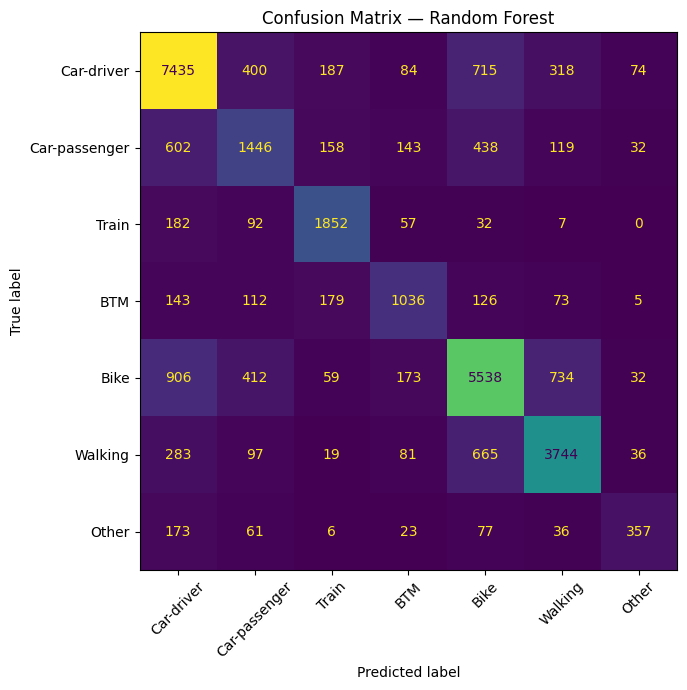


── XGBoost — Test set ──
               precision    recall  f1-score   support

   Car-driver       0.75      0.85      0.80      9213
Car-passenger       0.64      0.43      0.52      2938
        Train       0.79      0.85      0.82      2222
          BTM       0.74      0.59      0.66      1674
         Bike       0.72      0.77      0.74      7854
      Walking       0.79      0.73      0.76      4925
        Other       0.72      0.44      0.55       733

     accuracy                           0.74     29559
    macro avg       0.74      0.67      0.69     29559
 weighted avg       0.74      0.74      0.74     29559

Train accuracy: 0.7900 | Test accuracy: 0.7425 | Gap: 0.0476


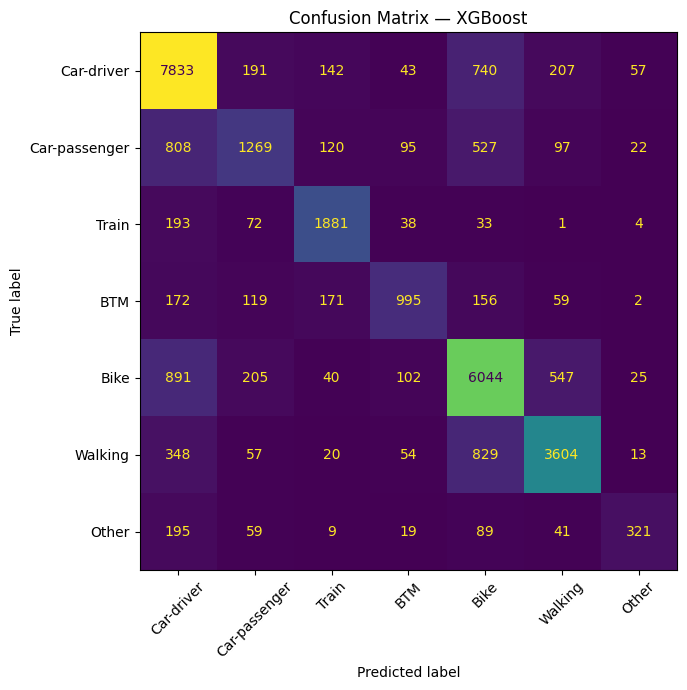

In [31]:
# Getting best parameters and testing them on the test set
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

best_rf.fit(X, y_train)
best_xgb.fit(X, y_train)

results_rows = []

for name, model in {"Random Forest": best_rf, "XGBoost": best_xgb}.items():
    y_pred = model.predict(X_test)

    print(f"\n── {name} — Test set ──")
    report = classification_report(
        y_test, y_pred,
        target_names=label_names,
        output_dict=True
    )
    print(classification_report(y_test, y_pred, target_names=label_names))

    # Store summary row
    results_rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        **{f"F1 {label_names[i]}": report[label_names[i]]["f1-score"]
           for i in range(len(label_names))}
    })

    # Train accuracy for overfitting check
    y_train_pred = model.predict(X)
    train_acc = (y_train_pred == y_train).mean()
    test_acc  = report["accuracy"]
    print(f"Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f} "
          f"| Gap: {train_acc - test_acc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

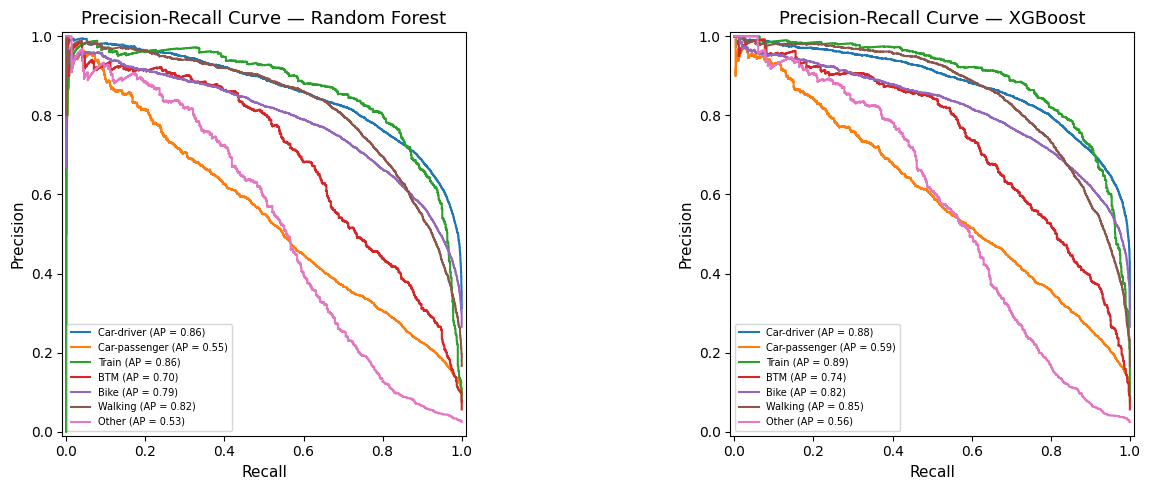

In [33]:
# Precision Recall plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, {"Random Forest": best_rf, "XGBoost": best_xgb}.items()):
    y_score = model.predict_proba(X_test)
    for i, label in enumerate(label_names):
        y_bin = (y_test == i).astype(int)
        ap = average_precision_score(y_bin, y_score[:, i])
        PrecisionRecallDisplay.from_predictions(
            y_bin, y_score[:, i],
            name=f"{label}", ax=ax
        )
    ax.set_title(f"Precision-Recall Curve — {name}", fontsize=13)
    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.savefig("precision_recall_curves.png", dpi=150)
plt.show()

# Model evaluation

XGBoost performed best, so this one is evaluated with SHAP values.

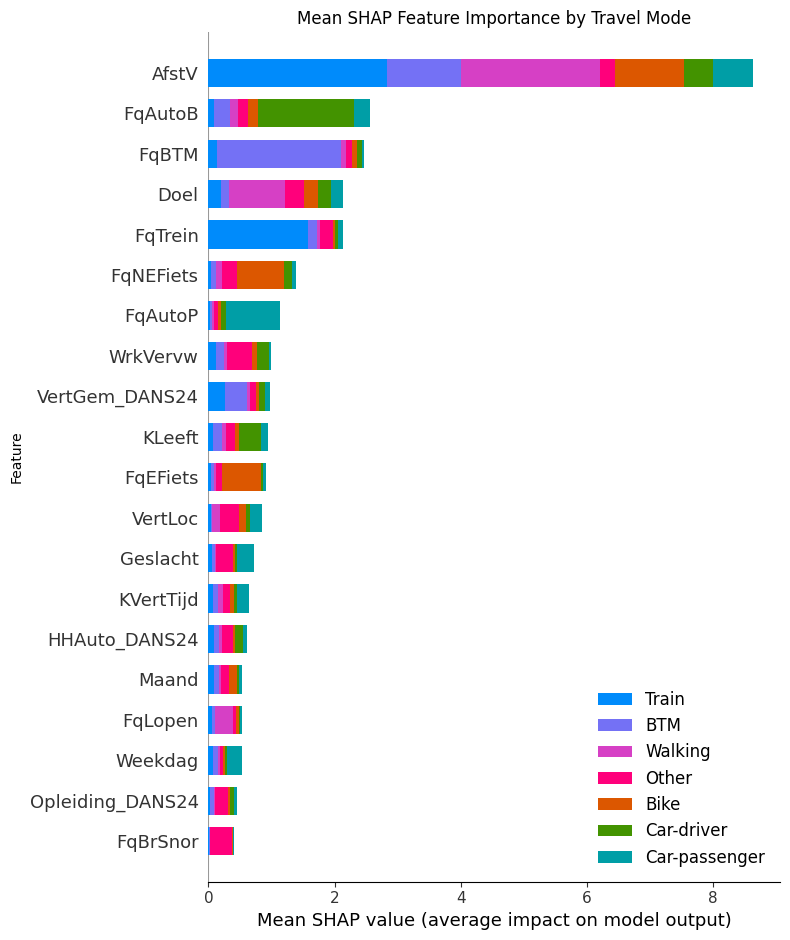

In [ ]:
best_final = best_xgb 

X_shap = X_test.sample(n=min(3000, len(X_test)), random_state=42)
X_shap_t = best_final.named_steps["preprocessor"].transform(X_shap)
feat_names_clean = [
    f.replace("remainder__", "").replace("num__", "")
    for f in best_final.named_steps["preprocessor"].get_feature_names_out()
]

explainer = shap.TreeExplainer(best_final.named_steps["classifier"])
shap_vals = explainer.shap_values(X_shap_t)

# Summary bar — mean SHAP across all classes
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    shap_vals, X_shap_t,
    feature_names=feat_names_clean,
    class_names=label_names,
    plot_type="bar",
    show=False
)
plt.gca().set_title("Mean SHAP Feature Importance by Travel Mode")
plt.gca().set_xlabel("Mean SHAP value (average impact on model output)")
plt.gca().set_ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()